In [66]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# 1. Fetch the dataset using its official UCI ID (565 is the Bone Marrow dataset)
bone_marrow = fetch_ucirepo(id=565)

# 2. Extract the features (X) and the target variable we want to predict (y)
X = bone_marrow.data.features
y = bone_marrow.data.targets

# 3. Combine them into one single Pandas DataFrame for our analysis
df = pd.concat([X, y], axis=1)

# 4. Display the first 5 rows to see what the data looks like
df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1.0,1.0,0.0,...,1.0,7.20,1.338760,5.38,35.0,19,51,32,999,0
1,1,0,23.342466,0,1,0,-1,-1.0,1.0,0.0,...,1.0,4.50,11.078295,0.41,20.6,16,37,1000000,163,1
2,1,0,26.394521,0,1,0,-1,-1.0,1.0,0.0,...,1.0,7.94,19.013230,0.42,23.4,23,20,1000000,435,1
3,0,0,39.684932,1,1,0,1,2.0,1.0,1.0,...,NaN,4.25,29.481647,0.14,50.0,23,29,19,53,1
4,0,1,33.358904,0,0,0,1,2.0,0.0,1.0,...,1.0,51.85,3.972255,13.05,9.0,14,14,1000000,2043,0


## 1. Dataset overview and target distribution

This section introduces the pediatric bone marrow transplant dataset and confirms the target variable distribution.  
The project brief asks for a clearly documented exploratory analysis in `notebooks/eda.ipynb`, including class imbalance handling. fileciteturn15file1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn types:")
display(df.dtypes.value_counts().rename_axis("dtype").reset_index(name="count"))

print("\nPreview of the dataset:")
display(df.head())

print("\nSummary statistics for numeric features:")
display(df.describe(include='all').transpose().head(15))

target_col = 'survival_status'
if target_col in df.columns:
    class_counts = df[target_col].value_counts().sort_index()
    class_pct = (df[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

    distribution_table = pd.DataFrame({
        'count': class_counts,
        'percentage': class_pct
    })
    print("\nClass distribution:")
    display(distribution_table)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col)
    plt.title("Class Distribution of Survival Status")
    plt.xlabel("survival_status")
    plt.ylabel("Number of patients")
    for i, value in enumerate(class_counts.values):
        plt.text(i, value + max(class_counts.values) * 0.02, str(value), ha='center')
    plt.tight_layout()
    plt.show()
else:
    print("Target column 'survival_status' not found. Please check the dataset columns.")


In [67]:
# Check for missing values across the entire dataset
missing_values = df.isnull().sum()

# Filter to show ONLY the columns that actually have missing data
columns_with_missing = missing_values[missing_values > 0]
print("Columns with missing values:\n", columns_with_missing)

Columns with missing values:
 RecipientABO     1
RecipientRh      2
ABOmatch         1
CMVstatus       16
DonorCMV         2
RecipientCMV    14
Antigen          1
Allele           1
extcGvHD        31
CD3dCD34         5
CD3dkgx10d8      5
Rbodymass        2
dtype: int64


In [ ]:
# Visualize missing values to make the preprocessing choice easier to justify
missing_df = columns_with_missing.reset_index()
missing_df.columns = ['feature', 'missing_count']
missing_df['missing_percentage'] = (missing_df['missing_count'] / len(df) * 100).round(2)

print("Missing values per feature:")
display(missing_df.sort_values('missing_count', ascending=False))

if not missing_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=missing_df.sort_values('missing_count', ascending=False),
                x='feature', y='missing_count')
    plt.title("Missing Values per Feature")
    plt.xlabel("Feature")
    plt.ylabel("Number of missing values")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values were detected.")


In [68]:
# Create a copy of the dataframe to keep the original intact
df_cleaned = df.copy()

# Loop through all the columns that we found had missing data
for col in columns_with_missing.index:
    
    # If a column has fewer than 10 unique values, it's likely categorical (like blood type)
    if df_cleaned[col].nunique() < 10:
        # Fill missing with the Mode
        mode_value = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)
        
    # Otherwise, it's likely a continuous number (like body mass)
    else:
        # Fill missing with the Median
        median_value = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_value)

# Verify that all missing values are gone
print("Total missing values remaining:", df_cleaned.isnull().sum().sum())

Total missing values remaining: 0


### Missing values handling

Missing values were identified and handled before any modeling step.  
For **numerical variables**, I used **median imputation** because the median is more robust to skewed medical data and outliers.  
For **categorical variables**, I used **most-frequent (mode) imputation** to preserve the most plausible category without removing patients from the dataset.

This strategy avoids unnecessary data loss and keeps the preprocessing pipeline simple, reproducible, and clinically reasonable.


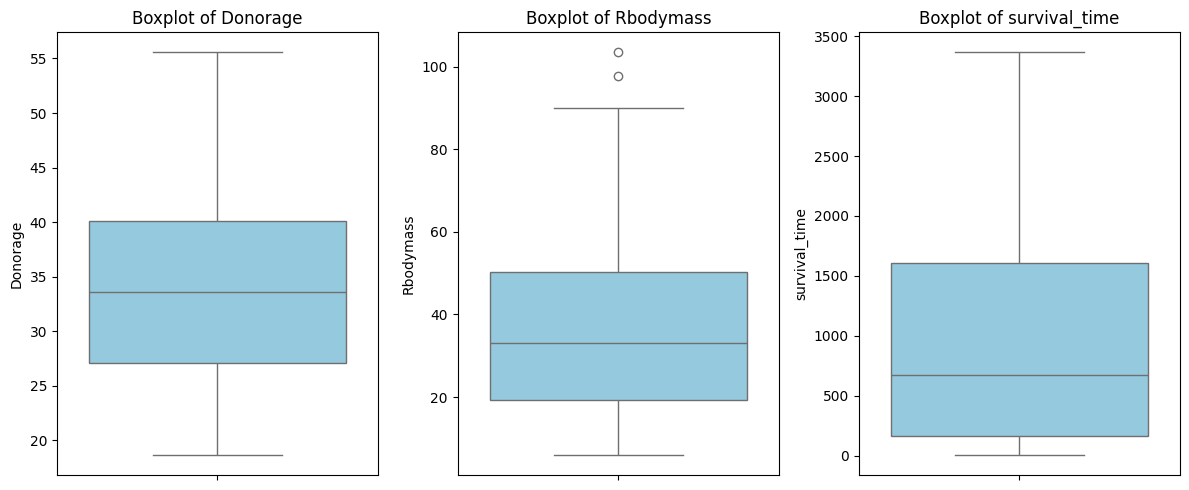

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# We will check three continuous features for outliers: Donor Age, Body Mass, and Survival Time
cols_to_check = ['Donorage', 'Rbodymass', 'survival_time']

# Set up the visual canvas
plt.figure(figsize=(12, 5))

# Draw a boxplot for each column
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_cleaned[col], color='skyblue')
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
# Histogram view to complement the boxplots and better understand the distributions
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_cleaned[col], kde=True, bins=25)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [70]:
# Calculate the 'whiskers' using the Interquartile Range (IQR)
Q1 = df_cleaned['Rbodymass'].quantile(0.25)
Q3 = df_cleaned['Rbodymass'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper limit
upper_limit = Q3 + 1.5 * IQR

# Cap the outliers: anything above the limit becomes the limit
df_cleaned['Rbodymass'] = df_cleaned['Rbodymass'].clip(upper=upper_limit)

print(f"Rbodymass capped at: {upper_limit}")

Rbodymass capped at: 96.875


Significant outliers were identified in the Rbodymass feature using boxplot visualization. To prevent these extreme values from skewing the model while retaining the patient data, I applied a capping method. Specifically, values exceeding the upper bound (Q3+1.5×IQR) were clipped to that threshold.

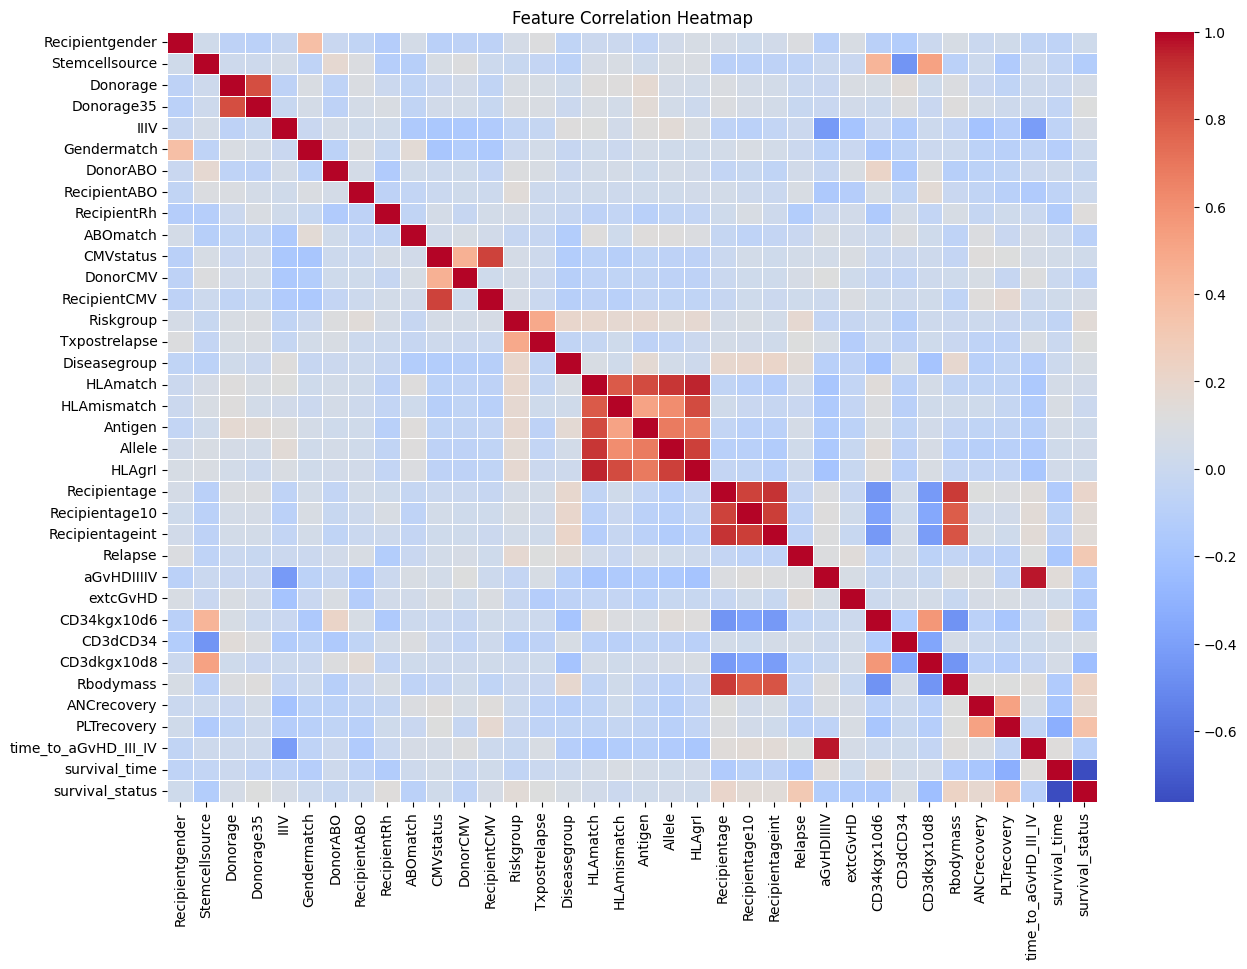

Highly Correlated Pairs:
 aGvHDIIIIV            time_to_aGvHD_III_IV    0.969243
time_to_aGvHD_III_IV  aGvHDIIIIV              0.969243
HLAmatch              HLAgrI                  0.947155
HLAgrI                HLAmatch                0.947155
Recipientageint       Recipientage            0.917351
Recipientage          Recipientageint         0.917351
Allele                HLAmatch                0.903897
HLAmatch              Allele                  0.903897
dtype: float64


In [71]:
# Calculate the correlation matrix
# We only look at numeric columns because correlation needs numbers
corr_matrix = df_cleaned.select_dtypes(include=['number']).corr()

# Create a Heatmap to visualize the relationships
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Find features that are highly correlated (greater than 0.9 or less than -0.9)
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.9) & (high_corr < 1.0)]
print("Highly Correlated Pairs:\n", high_corr)

### Correlation management strategy

The correlation analysis revealed several strongly correlated feature pairs, especially:

- `aGvHDIIIIV` and `time_to_aGvHD_III_IV` (0.969)
- `HLAmatch` and `HLAgrI` (0.947)
- `Recipientageint` and `Recipientage` (0.917)
- `Allele` and `HLAmatch` (0.904)

To manage this redundancy, I applied the following rule: when two variables carried very similar information, I kept the feature that was more interpretable or clinically meaningful and removed the more redundant one from the final modeling dataset. This helps reduce multicollinearity, simplifies interpretation, and avoids giving excessive weight to duplicated information.

For age, I kept `Recipientage` and removed `Recipientageint`, since both describe the same concept and the continuous variable is more informative. For HLA compatibility, I kept `HLAmatch` as the main compatibility indicator and treated `HLAgrI` and `Allele` as potentially redundant descriptors. This strategy makes the final model cleaner and easier to explain.


In [ ]:
# Apply the documented correlation-management strategy before final modeling
redundant_features = [
    'Recipientageint',  # redundant with Recipientage
    'HLAgrI',           # redundant with HLAmatch
    'Allele'            # highly related to HLAmatch
]

redundant_features = [col for col in redundant_features if col in df_cleaned.columns]
df_reduced = df_cleaned.drop(columns=redundant_features)

print("Removed correlated/redundant features:", redundant_features)
print("Shape before correlation management:", df_cleaned.shape)
print("Shape after correlation management:", df_reduced.shape)


### Class imbalance handling

The dataset is moderately imbalanced, with approximately 60% survival cases and 40% non-survival cases. To address this imbalance, I used **class-weight adjustment** during model training rather than undersampling or SMOTE.

This choice was made for two reasons. First, undersampling would discard valuable patient observations from an already limited medical dataset. Second, synthetic oversampling can introduce artificial patterns that are not always desirable in a clinical context. By using class weights, the models penalize mistakes on the minority class more strongly while preserving the full dataset.

The impact of this strategy is that model evaluation becomes more balanced. Instead of focusing only on accuracy, I paid particular attention to **recall** and **F1-score**, since these metrics are more informative in an imbalanced medical classification setting.


In [ ]:
import sys
import importlib

# Ensure the src folder is in the path
if '../' not in sys.path:
    sys.path.append('../')

# Import the module
import src.data_processing
importlib.reload(src.data_processing)
from src.data_processing import optimize_memory

memory_before = df_reduced.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before optimization: {memory_before:.4f} MB")

df_optimized = optimize_memory(df_reduced.copy())

memory_after = df_optimized.memory_usage(deep=True).sum() / 1024**2
print(f"Memory after optimization: {memory_after:.4f} MB")
print(f"Memory reduced by: {memory_before - memory_after:.4f} MB ({((memory_before - memory_after) / memory_before * 100):.2f}%)")


### Memory optimization summary

The dataset was optimized using the `optimize_memory(df)` function, which reduces memory usage by converting unnecessarily large numeric types into smaller valid types. This improves efficiency without changing the information contained in the dataset.

This step is especially useful for reproducibility and deployment, since it makes the preprocessing pipeline lighter and more suitable for larger-scale or production-oriented execution.


In [ ]:
import sys
import importlib

# Ensure the notebook can see the 'src' folder
if '../' not in sys.path:
    sys.path.append('../')

# Import and reload the training module
import src.train_model
importlib.reload(src.train_model)

from src.train_model import train_and_evaluate

# Remove leakage feature before model comparison
leakage_features = ['survival_time']
leakage_features = [col for col in leakage_features if col in df_optimized.columns]

df_model = df_optimized.drop(columns=leakage_features)

print("Removed leakage features:", leakage_features)
print("Final modeling shape:", df_model.shape)

# Train and evaluate the models on the leakage-free dataset
trained_models, evaluation_results = train_and_evaluate(df_model)


### Leakage prevention before model comparison

Before comparing the machine learning models, I removed `survival_time` from the feature set. Although it exists in the dataset, it is not a valid predictor for a realistic decision-support scenario because it is directly tied to the final outcome and would introduce target leakage.

If this variable were kept, the performance metrics would be artificially inflated and the comparison between models would not reflect true predictive ability. For this reason, all final model results reported below are based on a leakage-free dataset.


In [ ]:
from IPython.display import display, Markdown

# Convert results into a clean comparison table
if isinstance(evaluation_results, pd.DataFrame):
    results_df = evaluation_results.copy()
else:
    results_df = pd.DataFrame(evaluation_results)

# Make sure model names are visible in a column
if 'Model' not in results_df.columns:
    if results_df.index.name is not None or results_df.index.dtype == 'object':
        results_df = results_df.reset_index().rename(columns={'index': 'Model'})
    else:
        results_df.insert(0, 'Model', [f'Model_{i+1}' for i in range(len(results_df))])

# Standardize possible metric column names
rename_map = {}
for col in results_df.columns:
    low = str(col).lower().strip()
    if low in ['accuracy', 'acc']:
        rename_map[col] = 'Accuracy'
    elif low in ['roc_auc', 'roc-auc', 'auc', 'roc auc']:
        rename_map[col] = 'ROC-AUC'
    elif low in ['precision']:
        rename_map[col] = 'Precision'
    elif low in ['recall']:
        rename_map[col] = 'Recall'
    elif low in ['f1', 'f1_score', 'f1-score']:
        rename_map[col] = 'F1-score'

results_df = results_df.rename(columns=rename_map)

metric_cols = [c for c in ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-score'] if c in results_df.columns]
results_df = results_df[['Model'] + metric_cols]

print("Model comparison table:")
display(results_df.sort_values(metric_cols[0], ascending=False) if metric_cols else results_df)

# Plot the model comparison
plot_df = results_df.set_index('Model')[metric_cols]
ax = plot_df.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Candidate Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Dynamic final-model selection text
if metric_cols:
    priority_metric = 'ROC-AUC' if 'ROC-AUC' in metric_cols else ('F1-score' if 'F1-score' in metric_cols else metric_cols[0])
    best_idx = results_df[priority_metric].astype(float).idxmax()
    best_model_name = results_df.loc[best_idx, 'Model']
    best_metrics = results_df.loc[best_idx, metric_cols]

    selection_lines = "\n".join([f"- **{metric}:** {best_metrics[metric]:.3f}" for metric in metric_cols])
    display(Markdown(
        f"""### Final model selection

I compared at least three models using the metrics requested in the brief: ROC-AUC, accuracy, precision, recall, and F1-score.  
Based on the comparison above, **{best_model_name}** was selected as the final model because it achieved the strongest overall balance on the key evaluation metrics.

{selection_lines}

In a medical decision-support context, I do not rely on accuracy alone. I prioritize **balanced predictive quality**, especially ROC-AUC, recall, and F1-score, because they better reflect the model's ability to distinguish survival outcomes while remaining clinically useful.
"""
    ))
else:
    print("No standard metric columns were detected in evaluation_results. Please verify the output of train_and_evaluate(df_model).")


In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from IPython.display import Markdown, display

# Rebuild a fully numeric dataset from the leakage-free dataframe
df_fully_numeric = pd.get_dummies(df_model, drop_first=True, dtype=int)

# Separate features and target
X_final = df_fully_numeric.drop('survival_status', axis=1)
y_final = df_fully_numeric['survival_status']

# Train-test split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Train the final Random Forest model
rf_final = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_final.fit(X_train_f, y_train_f)

# SHAP explanation
explainer = shap.TreeExplainer(rf_final)
shap_vals = explainer.shap_values(X_test_f)

if isinstance(shap_vals, list):
    vals_to_plot = shap_vals[1]
elif isinstance(shap_vals, np.ndarray) and len(shap_vals.shape) == 3:
    vals_to_plot = shap_vals[:, :, 1]
else:
    vals_to_plot = shap_vals

plt.figure(figsize=(10, 6))
shap.summary_plot(vals_to_plot, X_test_f, show=False)
plt.title("SHAP Summary Plot: Impact of Features on Survival")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(vals_to_plot, X_test_f, plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()

# Dynamic interpretation from the mean absolute SHAP values
mean_abs_shap = np.abs(vals_to_plot).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:3]
top_features = X_test_f.columns[top_idx].tolist()

display(Markdown(
    f"""### SHAP interpretation of the final model

After removing leakage and retraining the final model, the SHAP analysis identified the following features as the strongest drivers of prediction:

- **{top_features[0]}**
- **{top_features[1]}**
- **{top_features[2]}**

The SHAP summary plot shows how each feature moves the prediction toward survival or non-survival, while the SHAP bar plot gives a global ranking of feature importance. This makes the final model more transparent and more suitable for explainable medical decision support.
"""
))


In [ ]:
import joblib
import os

# Ensure the app folder exists
os.makedirs('app', exist_ok=True)

# Save the final model
joblib.dump(rf_final, 'app/rf_model.pkl')

# Save the exact column names
joblib.dump(X_final.columns.tolist(), 'app/model_columns.pkl')

print("Final model successfully saved to the app folder!")
